In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

---

# OMP

In [ ]:
wdir = Path("logs/singleImage/OMP/")

In [95]:
staticData = pd.read_csv(wdir/"staticTimes.csv", sep=' ', names=["threads", "rows", "real", "user", "sys"], header=None)
dynamicData = pd.read_csv(wdir/"dynamicTimes.csv", sep=' ', names=["threads", "rows", "real", "user", "sys"], header=None)
staticData

,threads,rows,real,user,sys
0,2,512,0.014,0.023,0.001
1,2,512,0.015,0.023,0.003
2,2,512,0.013,0.022,0.002
3,2,512,0.014,0.023,0.001
4,2,512,0.014,0.024,0.000
...,...,...,...,...,...
2095,8,16384,10.963,79.128,0.434
2096,8,16384,10.946,79.567,0.437
2097,8,16384,10.931,79.041,0.443
2098,8,16384,10.973,79.210,0.405


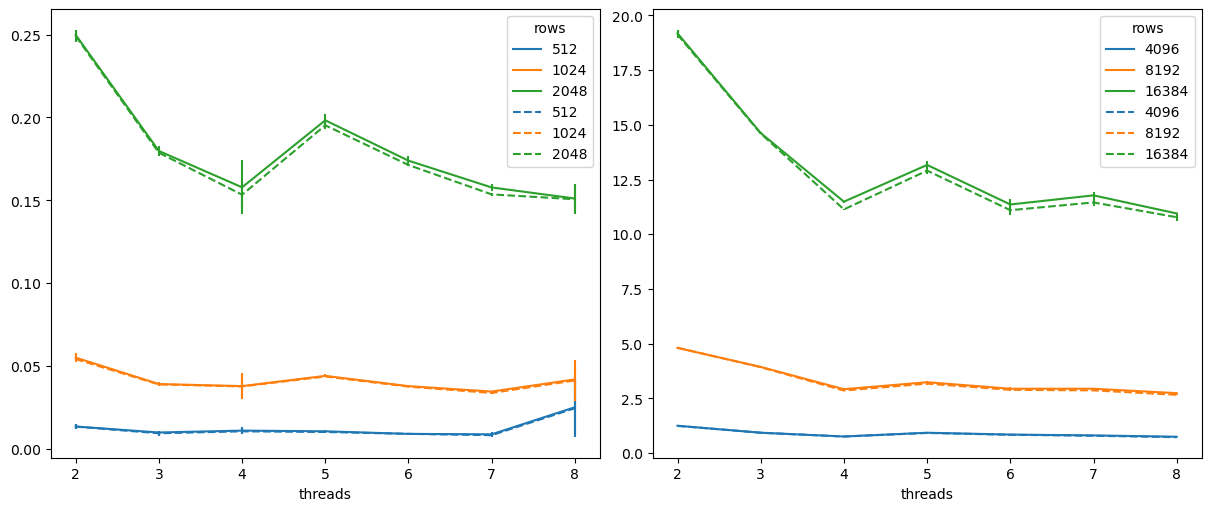

In [98]:
staticMeanStd = staticData.groupby(["threads", "rows"]).agg(["mean", "std"])["real"].unstack()
dynamicMeanStd = dynamicData.groupby(["threads", "rows"]).agg(["mean", "std"])["real"].unstack()

fig, ax = plt.subplots(1,2,figsize=(12,5), layout="constrained")
staticMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(y="mean", yerr="std", ax=ax[0])
ax[0].set_prop_cycle(None)
dynamicMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(y="mean", yerr="std", ls="--", ax=ax[0])

staticMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(y="mean", yerr="std", ax=ax[1])
ax[1].set_prop_cycle(None)
dynamicMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(y="mean", yerr="std", ls="--", ax=ax[1])

# meanStd.plot(y="mean", yerr="std")

plt.show()

---

In [101]:
statFunc.columns

Index(['threads', 'rows', 'center', 'rev', 'fft', 't', 'gauss', 'ifft'], dtype='str')

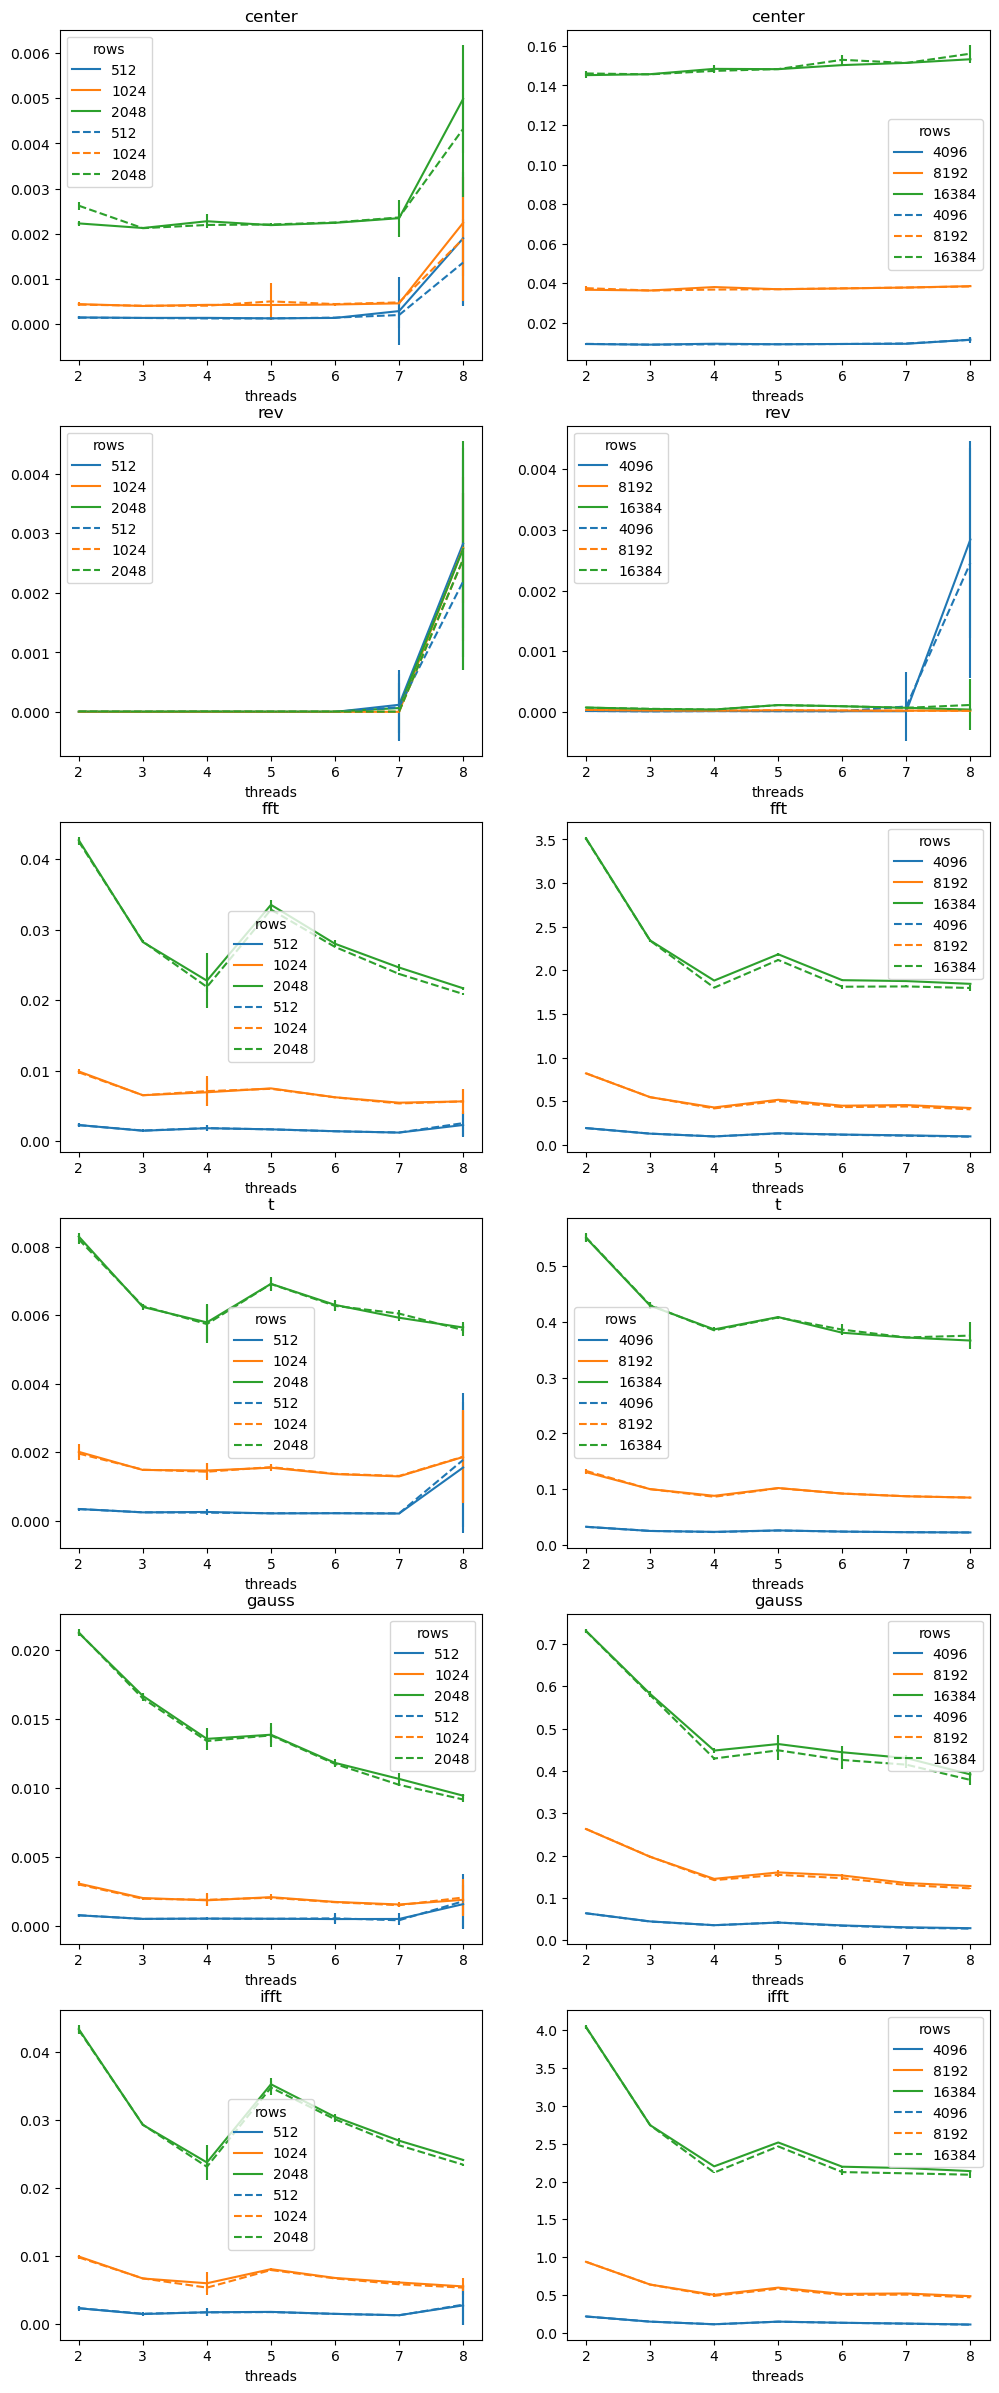

In [108]:
statFunc = pd.read_csv(wdir/"centerRevFftTGaussIfftStatic.csv", sep=' ', names=["threads", "rows", "center", "rev", "fft", "t", "gauss", "ifft"], header=None)
dynFunc = pd.read_csv(wdir/"centerRevFftTGaussIfftDynamic.csv", sep=' ', names=["threads", "rows", "center", "rev", "fft", "t", "gauss", "ifft"], header=None)

fig, ax = plt.subplots(len(statFunc.columns[2:]), 2, figsize=(12, 5*len(statFunc.columns[2:])))
for i, name in enumerate(statFunc.columns[2:]):
        statMeanStd = statFunc.groupby(["threads", "rows"]).agg(["mean", "std"])[name].unstack()
        dynMeanStd = dynFunc.groupby(["threads", "rows"]).agg(["mean", "std"])[name].unstack()
        
        statMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(y="mean", yerr="std", title=name, ax=ax[i,0])
        ax[i,0].set_prop_cycle(None)
        dynMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(y="mean", yerr="std", ls="--", ax=ax[i,0])
        
        statMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(y="mean", yerr="std", title=name, ax=ax[i,1])
        ax[i,1].set_prop_cycle(None)
        dynMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(y="mean", yerr="std", ls="--", ax=ax[i,1])
    

# CUDA

In [3]:
wdir = Path("logs/singleImage/cuda/")

In [10]:
cuData = pd.read_csv(wdir/"times.csv", sep=' ', names=["rows", "real", "user", "sys"], header=None)
cuMeanStd = cuData.groupby("rows").agg(["mean", "std"])["real"].unstack()
cuMeanStd

      rows 
mean  512      0.186260
      1024     0.193840
      2048     0.213230
      4096     0.302630
      8192     0.676520
      16384    2.212660
std   512      0.026865
      1024     0.006846
      2048     0.006796
      4096     0.004629
      8192     0.004164
      16384    0.004870
dtype: float64

# Comparison

In [53]:
data["rows"].unique()

array([  512,  1024,  2048,  4096,  8192, 16384])

dynamicTimes.csv


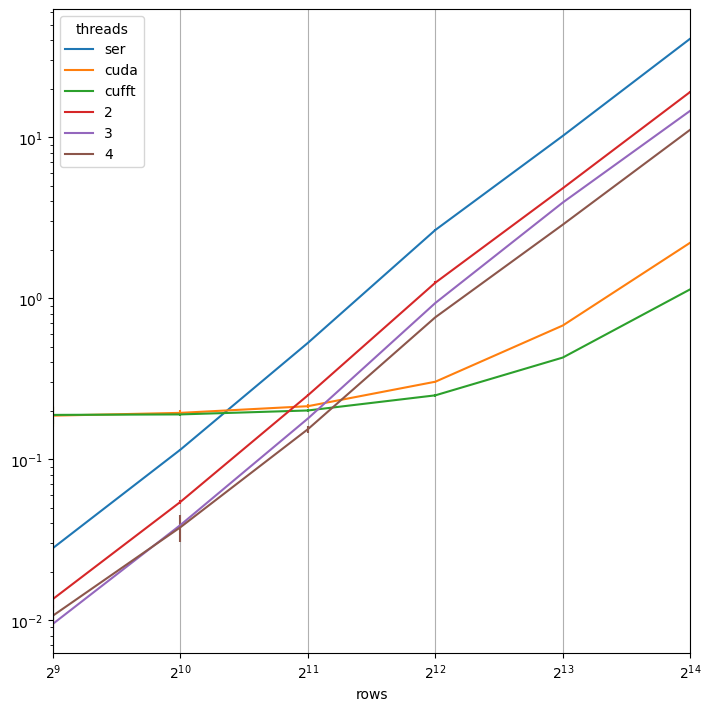

In [84]:
wdir = Path("logs/singleImage/")
pdNames = ["rows", "real", "user", "sys"]
fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.set_xlim(512, 16384)

for file in wdir.glob("**/times.csv"):
    data = pd.read_csv(file, sep=' ', names=pdNames, header=None)
    data.groupby("rows").agg(["mean", "std"])["real"].plot(y="mean", yerr="std", xticks=data["rows"].unique(), label=file.parent.name, ax=ax)
for file in wdir.glob("**/dynamicTimes.csv"):
    print(file.name)
    data = pd.read_csv(file, sep=' ', names=["threads"] + pdNames, header=None)
    data = data[(data["threads"]<=4)]
    data.groupby(["threads", "rows"]).agg(["mean", "std"])["real"].unstack(level=0).plot(y="mean", yerr="std", ax=ax)
    
ax.grid(axis="x")

plt.show()

In [ ]:
data = pd.read_csv(file, sep=' ', names= ["threads"] + pdNames if "T" in file.name else pdNames, header=None)
    data = data.groupby("rows" if "T" in file.name else ["threads", "rows"])

---

# 100 Images

In [104]:
wdir = Path("logs/multImages/")
pdNames = ["rows", "real", "user", "sys"]

for file in list((wdir.parent/"tesla").glob("*Streams.csv")) + list(wdir.glob("*.csv")):
    data = pd.read_csv(file, sep=' ', names=pdNames, header=None)
    print(file, data["real"].agg(["mean", "std"]).values)#.plot(y="mean", yerr="std", xticks=data["rows"].unique(), label=file.parent.name, ax=ax)

logs/tesla/1Streams.csv [12.41368     0.11940593]
logs/tesla/2Streams.csv [6.75749    0.27346104]
logs/multImages/3Streams.csv [9.77686    0.03354118]
logs/multImages/2Streams.csv [9.75727    0.03576095]
logs/multImages/1Streams.csv [10.71332     0.03444946]
logs/multImages/ser.csv [230.89344      0.33060703]
logs/multImages/omp.csv [69.8962      0.53227022]
logs/multImages/omp4Cores.csv [73.42436364  0.22037063]
logs/multImages/cufft1Stream.csv [4.89473    0.04784083]
logs/multImages/cufft2Streams.csv [3.85517    0.06509854]
